In [1]:
from typing_extensions import TypedDict
from typing import List
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from pydantic import BaseModel

llm = init_chat_model(model="llama3.1:8B", model_provider="ollama")

In [2]:
class State(TypedDict):
    dish: str
    ingredients: list[dict]
    recipe_steps: str
    plating_instructions: str

class Ingredient(BaseModel):
    name: str
    quantity: str
    unit: str

class IngredientsOutput(BaseModel):
    ingredients: List[Ingredient]

In [3]:
def list_ingredients(state: State):
    structured_llm = llm.with_structured_output(IngredientsOutput)
    response = structured_llm.invoke(
        f"List 5-8 ingredients needed to make {state["dish"]}"
    )
    return {"ingredients": response.ingredients}


def create_recipe(state: State):
    response = llm.invoke(
        f"Write a step by step cooking instruction for {state["dish"]}, using these ingredients {state['ingredients']}"
    )
    return {"recipe_steps": response.content}


def describe_plating(state: State):
    response = llm.invoke(
        f"Describe how to beautifully plate this dish {state["dish"]} based on this recipe {state["recipe_steps"]}"
    )
    return {"plating_instructions": response.content}

def gate(state: State):
    ingredients = state["ingredients"]

    if len(ingredients) > 8 or len(ingredients) < 3:
        return False
    
    return True

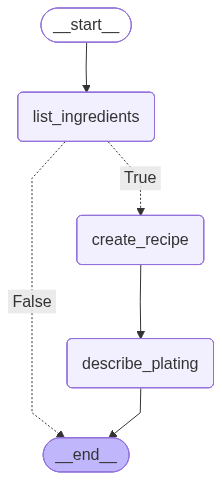

In [4]:
graph_builder = StateGraph(State)

graph_builder.add_node("list_ingredients", list_ingredients)
graph_builder.add_node("create_recipe", create_recipe)
graph_builder.add_node("describe_plating", describe_plating)

graph_builder.add_edge(START, "list_ingredients")
graph_builder.add_conditional_edges(
    "list_ingredients",
    gate,
    {
        True: "create_recipe",
        False: END,
    },
)
graph_builder.add_edge("create_recipe", "describe_plating")
graph_builder.add_edge("describe_plating", END)

graph = graph_builder.compile()

graph

In [5]:
graph.invoke({ "dish": "hummus" })

{'dish': 'hummus',
 'ingredients': [Ingredient(name='chickpeas (or garbanzo beans)', quantity='1 can (15 ounces) ', unit='cans'),
  Ingredient(name='lemon juice', quantity='2 tablespoons', unit='tablespoon'),
  Ingredient(name='tahini', quantity='@ 1/4 cup ', unit='cup'),
  Ingredient(name='garlic', quantity='1 clove ', unit='clove'),
  Ingredient(name='olive oil', quantity='@ 2 tablespoons ', unit='tablespoon'),
  Ingredient(name='salt', quantity='to taste', unit='pinch')],
 'recipe_steps': "Here's a step-by-step cooking instruction for hummus using the given ingredients:\n\n**Hummus Recipe**\n\n**Servings:** Approximately 8-10 servings\n\n**Preparation Time:** 5 minutes\n**Cooking Time:** 0 minutes (hummus is a no-cook dish)\n**Total Time:** 5 minutes\n\n**Ingredients:**\n\n* 1 can (15 ounces) chickpeas (or garbanzo beans)\n* 2 tablespoons lemon juice\n* @ 1/4 cup tahini\n* 1 clove garlic\n* @ 2 tablespoons olive oil\n* Salt, to taste\n\n**Instructions:**\n\n1. **Drain and rinse the 